# GNN Candidate Screening Workflow

This notebook runs inference over a GNN dataset to predict activation energies and rank materials for further MACE evaluation.

## 1. Configuration

In [8]:
import os
import sys
import torch
import pandas as pd
import libraries.screen_candidates as sc
import importlib

# Reload to ensure latest changes
importlib.reload(sc)

# --- SETTINGS ---
MODEL_DIR = "models/all-energies/results_20260510_125735"
DATASET_PATH = "models/all-energies/dataset.pt"
STD_PARAMS_PATH = "models/all-energies/standardized_parameters.json"

# --- RANKING METHOD ---
# Set to None for single target ranking, or a dict for weighted sum
# Example: {"E_3D": 0.6, "E_2D": 0.3, "E_1D": 0.1}
WEIGHTS = {"E_3D": 0.7, "E_2D": 0.2, "E_1D": 0.1}
TARGET = "E_3D"           # Ranking target (used only if WEIGHTS is None)

TOP_N = 10                # Number of candidates to export to candidates.txt
BATCH_SIZE = 32
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CANDIDATES_TXT = "candidates.txt"
PREDICTIONS_CSV = "candidate_predictions.csv"

print(f"Using device: {DEVICE}")

Using device: cpu


## 2. Load Model

In [9]:
print(f"Loading model from {MODEL_DIR}...")
model, model_params = sc.load_screening_model(MODEL_DIR, device=DEVICE)
print("Model loaded successfully.")

Loading model from models/all-energies/results_20260510_125735...
Instantiating FDGNN with 5 features and 3 outputs...
Model loaded successfully.


## 3. Load Dataset

In [10]:
print(f"Loading dataset from {DATASET_PATH}...")
dataset_std, std_params = sc.load_screening_dataset(DATASET_PATH, STD_PARAMS_PATH, model_params)
print(f"Loaded {len(dataset_std)} samples.")

Loading dataset from models/all-energies/dataset.pt...


Standardizing dataset...


Loaded 3862 samples.


## 4. Run Inference

In [11]:
print("Running inference over all samples...")
results = sc.run_inference(
    model=model, 
    dataset=dataset_std, 
    device=DEVICE, 
    std_params=std_params, 
    model_params=model_params, 
    batch_size=BATCH_SIZE
)
print(f"Inference complete. Processed {len(results)} materials.")

Running inference over all samples...


Inference: 100%|██████████| 121/121 [01:41<00:00,  1.20it/s]

Inference complete. Processed 3862 materials.


## 5. Rank Candidates

In [12]:
print("Ranking candidates...")
ranked_df, ranking_formula = sc.rank_candidates(results, target=TARGET, weights=WEIGHTS)
print("Ranking complete.")
display(ranked_df.head(TOP_N))

Ranking candidates...
Ranking by weighted sum: 0.7*E_3D + 0.2*E_2D + 0.1*E_1D
Ranking complete.


,material,symmetry,label,E_1D,E_2D,E_3D,ranking_score,rank
0,Li2O,Fm-3m,Li2O Fm-3m,0.624576,0.349364,0.074248,0.184304,1
1,Li2S,Fm-3m,Li2S Fm-3m,0.373449,0.312839,0.122927,0.185961,2
2,LiI,P6_3mc,LiI P6_3mc,0.136895,0.112167,0.221040,0.190851,3
3,LiI,Fm-3m,LiI Fm-3m,0.136897,0.112174,0.221054,0.190863,4
4,LiI,P6_3-mmc,LiI P6_3-mmc,0.181669,0.138463,0.210890,0.193483,5
5,Li2Se,Fm-3m,Li2Se Fm-3m,0.470070,0.309435,0.128162,0.198608,6
6,Li9S3N,Pm-3m,Li9S3N Pm-3m,0.490086,0.348454,0.133020,0.211813,7
7,Li7IN2,Cm,Li7IN2 Cm,0.500858,0.299828,0.147678,0.213426,8
8,Li3BrO,Pm-3m,Li3BrO Pm-3m,0.596762,0.327627,0.129952,0.216168,9
9,Li8TeN2,I4_1md,Li8TeN2 I4_1md,0.501247,0.321947,0.149883,0.219432,10


## 6. Visualization

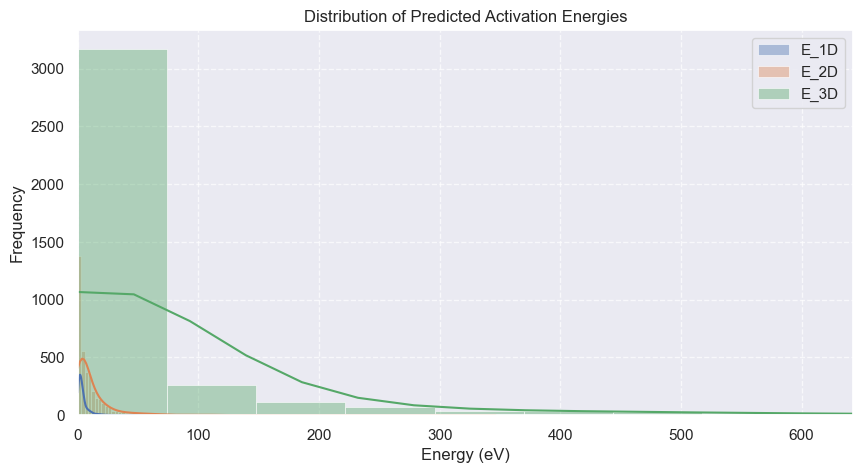

c:\Users\mateu\Desktop\gnn-material-science\gnn-material-science\gnn-material-science\libraries\screen_candidates.py:251: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_df, x='ranking_score', y='display_label', palette='viridis')


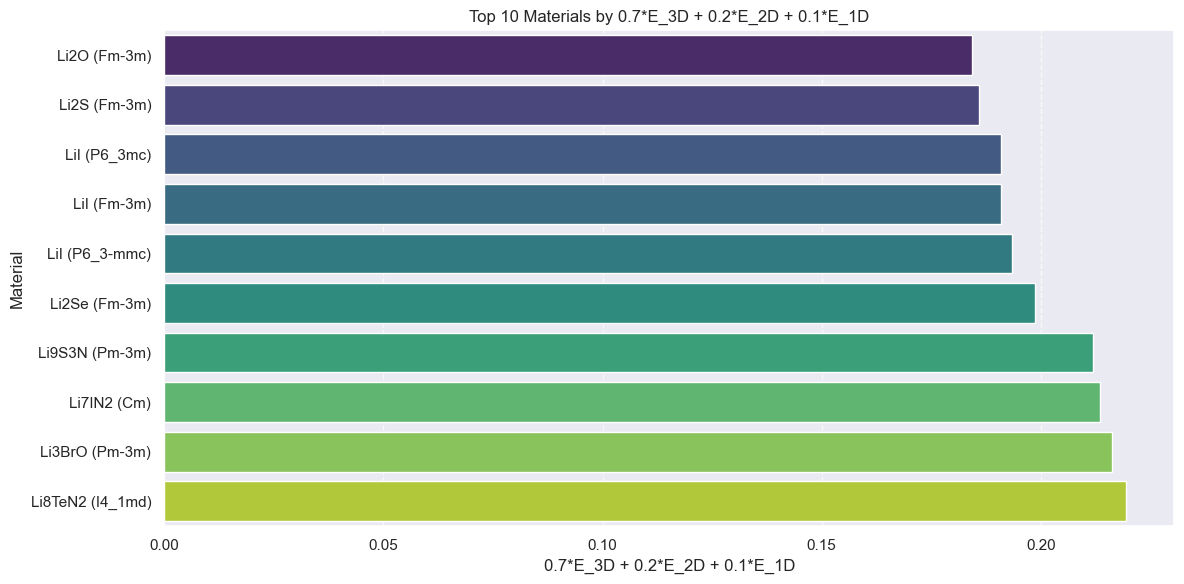

In [13]:
# Plot distribution of predictions
sc.plot_energy_distributions(results)

# Plot top candidates bar chart
sc.plot_top_candidates(ranked_df, top_n=TOP_N, label=ranking_formula)

## 7. Export Outputs

In [14]:
# Export candidates.txt for run-MACE.ipynb
sc.write_candidates_txt(ranked_df, TOP_N, CANDIDATES_TXT)

# Export full CSV for analysis
sc.write_predictions_csv(ranked_df, PREDICTIONS_CSV)

Exported top 10 candidates to candidates.txt
Exported all predictions to candidate_predictions.csv
